# Kaplan-Meier -- Analyse de survie par groupe

Objectif : estimer la courbe de survie S(t) pour chaque groupe (global, aeroport, saison)
et trouver T* tel que le risque conditionnel reste sous le seuil voulu.

Risque conditionnel : Risk(T) = 1 - S(30) / S(T)
= probabilite qu'un eclair arrive entre T et 30 min, sachant qu'il ne s'en est pas produit jusqu'a T.

Question centrale : peut-on descendre sous 2% de risque ? Pour quels groupes ?

## SECTION 1 : Chargement des donnees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

In [2]:
df            = pd.read_parquet('data_df.parquet')
df_with_alert = pd.read_parquet('data_df_with_alert.parquet')

df['date']            = pd.to_datetime(df['date'], utc=True)
df_with_alert['date'] = pd.to_datetime(df_with_alert['date'], utc=True)

print('df            :', df.shape)
print('df_with_alert :', df_with_alert.shape)
print('Aeroports     :', sorted(df_with_alert['airport'].unique()))
print('Annees        :', sorted(df_with_alert['date'].dt.year.unique()))

df            : (507071, 14)
df_with_alert : (56599, 15)
Aeroports     : ['Ajaccio', 'Bastia', 'Biarritz', 'Nantes', 'Pise']
Annees        : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]


## SECTION 2 : Construction de la variable de survie

Pour chaque eclair i dans une alerte :
- duree = silence jusqu'au prochain eclair (minutes)
- event = True  si un eclair suit (silence reel observe)
- event = False si c'est le dernier eclair (censure a 30 min : on sait juste que silence >= 30)

In [3]:
# Tri chronologique par alerte
df_surv = df_with_alert.sort_values(['airport', 'airport_alert_id', 'date']).copy()

# Saison
saison_map = {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}
df_surv['saison'] = df_surv['mois'].map(saison_map)
saison_labels     = {0:'Hiver', 1:'Printemps', 2:'Ete', 3:'Automne'}

# Variable cible : silence jusqu'au prochain eclair
g = df_surv.groupby(['airport', 'airport_alert_id'])
df_surv['duree'] = g['silence_minute'].shift(-1)

# Dernier eclair : censure a 30 min
mask_last = df_surv['is_last_lightning_cloud_ground'] == True
df_surv.loc[mask_last, 'duree'] = 30.0
df_surv['event'] = (~mask_last).astype(bool)

print(f'Observations totales    : {len(df_surv):,}')
print(f'event=True  (non cens.) : {df_surv["event"].sum():,}  ({df_surv["event"].mean()*100:.1f}%)')
print(f'event=False (censures)  : {(~df_surv["event"]).sum():,}  ({(~df_surv["event"]).mean()*100:.1f}%)')

Observations totales    : 56,599
event=True  (non cens.) : 53,972  (95.4%)
event=False (censures)  : 2,627  (4.6%)


## SECTION 3 : Kaplan-Meier global -- baseline

KM GLOBAL
S(30) = 0.0464  (4.64%)

  Seuil risque       T*    Risk reel     Gain
--------------------------------------------------
           2%     28.5        1.98%     1.5 min
           5%     25.9        4.99%     4.1 min
          10%     22.7        9.97%     7.3 min
          15%     19.6       14.98%    10.4 min


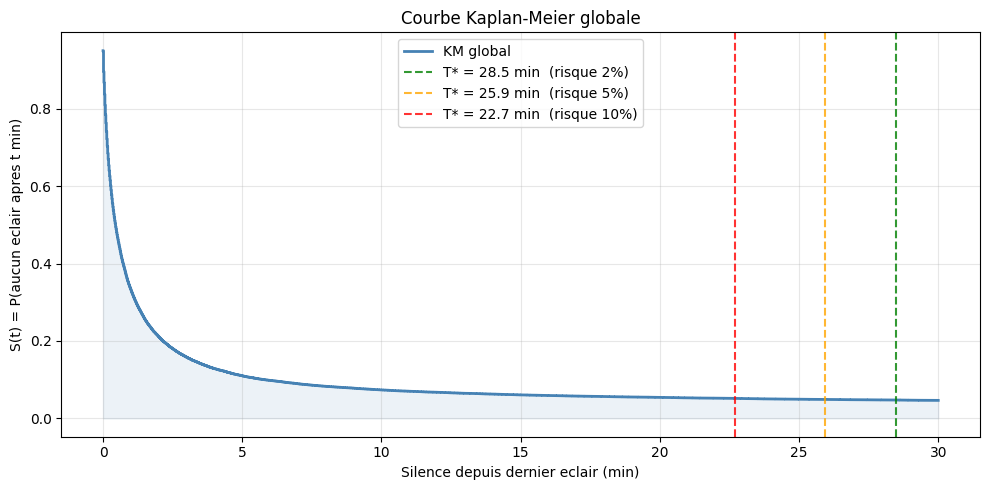

In [4]:
# Courbe KM globale sur tous les eclairs (toutes alertes, tous aeroports)
df_km = df_surv.dropna(subset=['duree']).copy()

t_km, s_km = kaplan_meier_estimator(df_km['event'].values, df_km['duree'].values)

# Trouver T* pour plusieurs seuils de risque
# Risk(T) = 1 - S(30) / S(T) <= seuil
# => S(T) >= S(30) / (1 - seuil)
s30 = float(np.interp(30, t_km, s_km))

def trouver_t_star(t_km, s_km, seuil_risque):
    """Trouver le plus petit T tel que Risk(T) <= seuil."""
    s30 = float(np.interp(30, t_km, s_km))
    seuil_s = s30 / (1 - seuil_risque)  # S(T*) >= cette valeur
    idx = np.searchsorted(-s_km, -seuil_s)  # premier t ou S(t) <= seuil_s
    if idx >= len(t_km):
        return float('nan'), float('nan')
    t_star = t_km[idx]
    s_t    = s_km[idx]
    risk   = 1 - s30 / s_t if s_t > 0 else 1.0
    return t_star, risk

print('KM GLOBAL')
print(f'S(30) = {s30:.4f}  ({s30*100:.2f}%)')
print()
print(f'{"Seuil risque":>14} {"T*":>8} {"Risk reel":>12} {"Gain":>8}')
print('-' * 50)
for seuil in [0.02, 0.05, 0.10, 0.15]:
    t_star, risk = trouver_t_star(t_km, s_km, seuil)
    gain = 30 - t_star if not np.isnan(t_star) else 0
    print(f'{seuil*100:>12.0f}%  {t_star:>7.1f}  {risk*100:>10.2f}%  {gain:>6.1f} min')

# Graphique
plt.figure(figsize=(10, 5))
plt.step(t_km, s_km, where='post', color='steelblue', linewidth=2, label='KM global')
plt.fill_between(t_km, s_km, alpha=0.1, color='steelblue', step='post')
for seuil, color in [(0.02,'green'), (0.05,'orange'), (0.10,'red')]:
    t_star, risk = trouver_t_star(t_km, s_km, seuil)
    if not np.isnan(t_star):
        plt.axvline(t_star, color=color, linestyle='--', alpha=0.8,
                    label=f'T* = {t_star:.1f} min  (risque {seuil*100:.0f}%)')
plt.xlabel('Silence depuis dernier eclair (min)')
plt.ylabel('S(t) = P(aucun eclair apres t min)')
plt.title('Courbe Kaplan-Meier globale')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('km_global.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 4 : Kaplan-Meier par aeroport

Question : les aeroports ont-ils des profils d'orage differents ?
Un aeroport avec des orages plus courts pourrait beneficier d'un T* plus bas.
On cherche pour chaque aeroport le T* a 2% de risque.

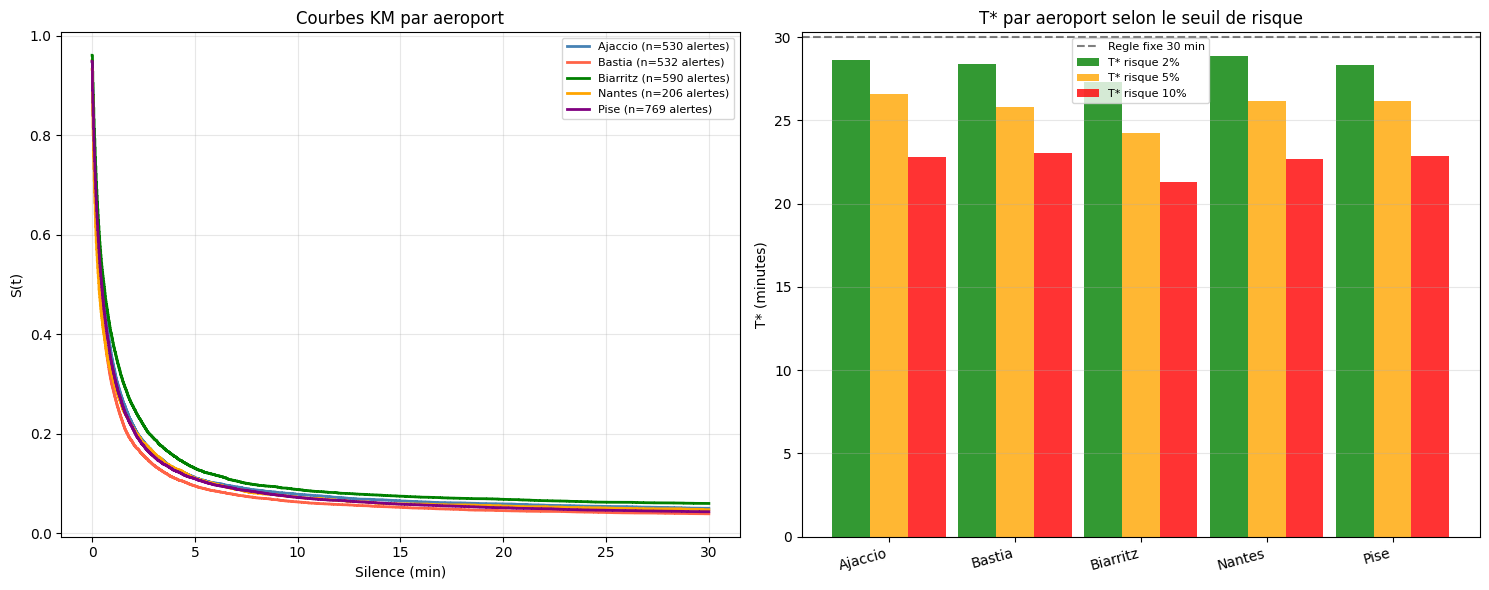


TABLEAU KM PAR AEROPORT
Aeroport      N alertes    S(30)    T* 2%   Gain 2%    T* 5%   Gain 5%
--------------------------------------------------------------------------------
Ajaccio             530   0.0498     28.6   1.4 min     26.6   3.4 min
Bastia              532   0.0387     28.4   1.6 min     25.8   4.2 min
Biarritz            590   0.0595     27.3   2.7 min     24.3   5.7 min
Nantes              206   0.0471     28.9   1.1 min     26.2   3.8 min
Pise                769   0.0429     28.3   1.7 min     26.1   3.9 min


In [5]:
airports = sorted(df_surv['airport'].unique())
colors_ap = ['steelblue', 'tomato', 'green', 'orange', 'purple', 'brown']

resultats_ap = []

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for airport, color in zip(airports, colors_ap):
    sub = df_surv[df_surv['airport'] == airport].dropna(subset=['duree'])
    n_alertes = sub['airport_alert_id'].nunique()
    t, s = kaplan_meier_estimator(sub['event'].values, sub['duree'].values)
    s30_ap = float(np.interp(30, t, s))
    t2, r2   = trouver_t_star(t, s, 0.02)
    t5, r5   = trouver_t_star(t, s, 0.05)
    t10, r10 = trouver_t_star(t, s, 0.10)
    resultats_ap.append({
        'airport': airport, 'n_eclairs': len(sub), 'n_alertes': n_alertes,
        'S(30)': s30_ap,
        'T* 2%': t2,  'Risk 2%': r2,  'Gain 2%': 30 - t2 if not np.isnan(t2) else 0,
        'T* 5%': t5,  'Risk 5%': r5,  'Gain 5%': 30 - t5 if not np.isnan(t5) else 0,
        'T* 10%': t10,'Risk 10%': r10,'Gain 10%': 30 - t10 if not np.isnan(t10) else 0,
    })
    ax.step(t, s, where='post', color=color, linewidth=2,
            label=f'{airport} (n={n_alertes} alertes)')

ax.set_xlabel('Silence (min)')
ax.set_ylabel('S(t)')
ax.set_title('Courbes KM par aeroport')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# T* a 2% et 5% par aeroport
df_res_ap = pd.DataFrame(resultats_ap)
ax2 = axes[1]
x   = np.arange(len(airports))
w   = 0.3
ax2.bar(x - w, df_res_ap['T* 2%'],  w, label='T* risque 2%',  color='green',  alpha=0.8)
ax2.bar(x,     df_res_ap['T* 5%'],  w, label='T* risque 5%',  color='orange', alpha=0.8)
ax2.bar(x + w, df_res_ap['T* 10%'], w, label='T* risque 10%', color='red',    alpha=0.8)
ax2.axhline(30, color='black', linestyle='--', alpha=0.5, label='Regle fixe 30 min')
ax2.set_xticks(x)
ax2.set_xticklabels(airports, rotation=15, ha='right')
ax2.set_ylabel('T* (minutes)')
ax2.set_title('T* par aeroport selon le seuil de risque')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('km_par_aeroport.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 80)
print('TABLEAU KM PAR AEROPORT')
print('=' * 80)
print(f"{'Aeroport':<12} {'N alertes':>10} {'S(30)':>8} {'T* 2%':>8} {'Gain 2%':>9} {'T* 5%':>8} {'Gain 5%':>9}")
print('-' * 80)
for _, row in df_res_ap.iterrows():
    t2_str  = f"{row['T* 2%']:.1f}" if not np.isnan(row['T* 2%']) else 'impossible'
    g2_str  = f"{row['Gain 2%']:.1f} min" if not np.isnan(row['T* 2%']) else '--'
    t5_str  = f"{row['T* 5%']:.1f}"
    g5_str  = f"{row['Gain 5%']:.1f} min"
    print(f"{row['airport']:<12} {int(row['n_alertes']):>10} {row['S(30)']:>8.4f} {t2_str:>8} {g2_str:>9} {t5_str:>8} {g5_str:>9}")

## SECTION 5 : Kaplan-Meier par saison

Question : les orages d'ete se terminent-ils differemment de ceux d'hiver ?
La saisonnalite peut justifier un T* different selon la periode de l'annee.

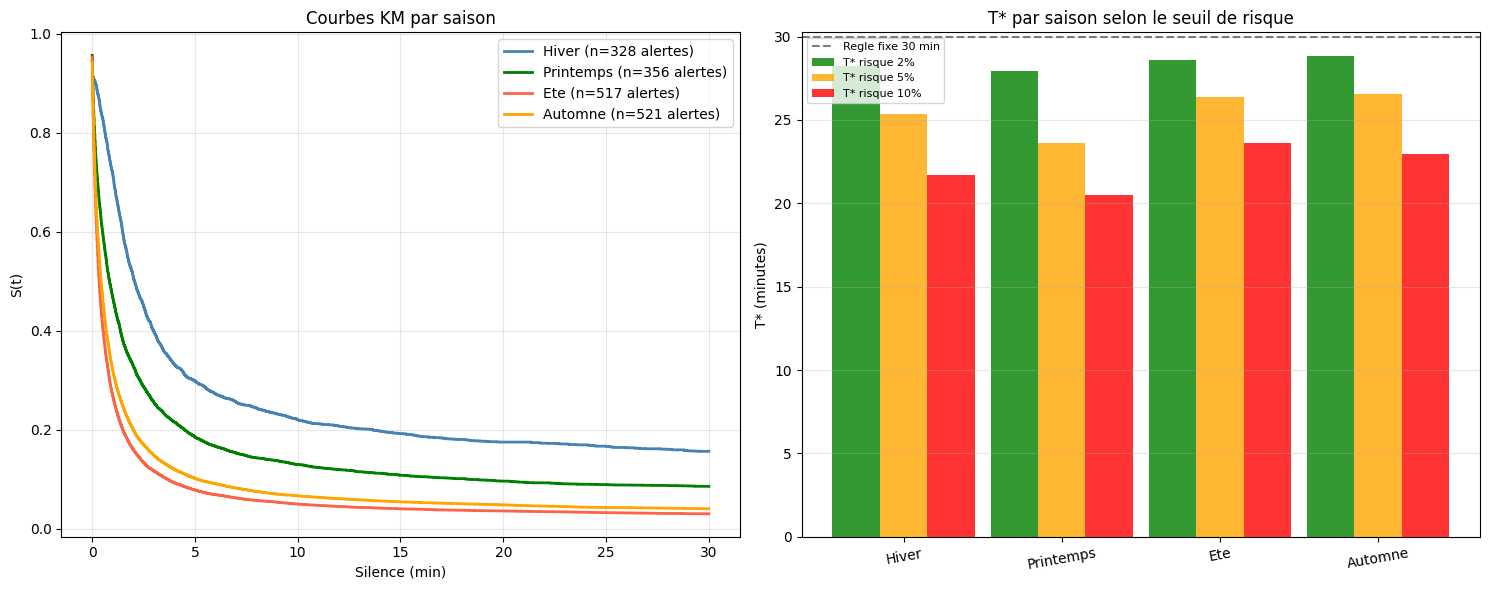


TABLEAU KM PAR SAISON
Saison        N alertes    S(30)    T* 2%   Gain 2%    T* 5%   Gain 5%
--------------------------------------------------------------------------------
Hiver               328   0.1565     28.2   1.8 min     25.4      4.6 min
Printemps           356   0.0857     28.0   2.0 min     23.6      6.4 min
Ete                 517   0.0302     28.6   1.4 min     26.4      3.6 min
Automne             521   0.0403     28.8   1.2 min     26.5      3.5 min


In [6]:
saison_colors = {0:'steelblue', 1:'green', 2:'tomato', 3:'orange'}
resultats_sais = []

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]

for sais_id, sais_label in saison_labels.items():
    sub = df_surv[df_surv['saison'] == sais_id].dropna(subset=['duree'])
    n_alertes = sub['airport_alert_id'].nunique()
    if len(sub) < 50:
        continue
    t, s = kaplan_meier_estimator(sub['event'].values, sub['duree'].values)
    s30_s  = float(np.interp(30, t, s))
    t2, r2   = trouver_t_star(t, s, 0.02)
    t5, r5   = trouver_t_star(t, s, 0.05)
    t10, r10 = trouver_t_star(t, s, 0.10)
    resultats_sais.append({
        'saison': sais_label, 'n_eclairs': len(sub), 'n_alertes': n_alertes,
        'S(30)': s30_s,
        'T* 2%': t2,  'Gain 2%': 30 - t2 if not np.isnan(t2) else 0,
        'T* 5%': t5,  'Gain 5%': 30 - t5 if not np.isnan(t5) else 0,
        'T* 10%': t10,'Gain 10%': 30 - t10 if not np.isnan(t10) else 0,
    })
    ax.step(t, s, where='post', color=saison_colors[sais_id], linewidth=2,
            label=f'{sais_label} (n={n_alertes} alertes)')

ax.set_xlabel('Silence (min)')
ax.set_ylabel('S(t)')
ax.set_title('Courbes KM par saison')
ax.legend()
ax.grid(alpha=0.3)

df_res_sais = pd.DataFrame(resultats_sais)
ax2 = axes[1]
x = np.arange(len(df_res_sais))
w = 0.3
ax2.bar(x - w, df_res_sais['T* 2%'],  w, label='T* risque 2%',  color='green',  alpha=0.8)
ax2.bar(x,     df_res_sais['T* 5%'],  w, label='T* risque 5%',  color='orange', alpha=0.8)
ax2.bar(x + w, df_res_sais['T* 10%'], w, label='T* risque 10%', color='red',    alpha=0.8)
ax2.axhline(30, color='black', linestyle='--', alpha=0.5, label='Regle fixe 30 min')
ax2.set_xticks(x)
ax2.set_xticklabels(df_res_sais['saison'], rotation=10)
ax2.set_ylabel('T* (minutes)')
ax2.set_title('T* par saison selon le seuil de risque')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('km_par_saison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 80)
print('TABLEAU KM PAR SAISON')
print('=' * 80)
print(f"{'Saison':<12} {'N alertes':>10} {'S(30)':>8} {'T* 2%':>8} {'Gain 2%':>9} {'T* 5%':>8} {'Gain 5%':>9}")
print('-' * 80)
for _, row in df_res_sais.iterrows():
    t2_str = f"{row['T* 2%']:.1f}" if not np.isnan(row['T* 2%']) else 'impossible'
    g2_str = f"{row['Gain 2%']:.1f} min" if not np.isnan(row['T* 2%']) else '--'
    print(f"{row['saison']:<12} {int(row['n_alertes']):>10} {row['S(30)']:>8.4f} {t2_str:>8} {g2_str:>9} {row['T* 5%']:>8.1f} {row['Gain 5%']:>8.1f} min")

## SECTION 6 : Tableau croise aeroport x saison -- peut-on atteindre 2% ?

On calcule le T* a 2% pour chaque combinaison aeroport x saison.
Si T* est NaN : pas assez de donnees ou la courbe ne descend jamais sous le seuil.
Un gain positif confirme qu'on peut descendre sous 2% pour ce groupe specifique.

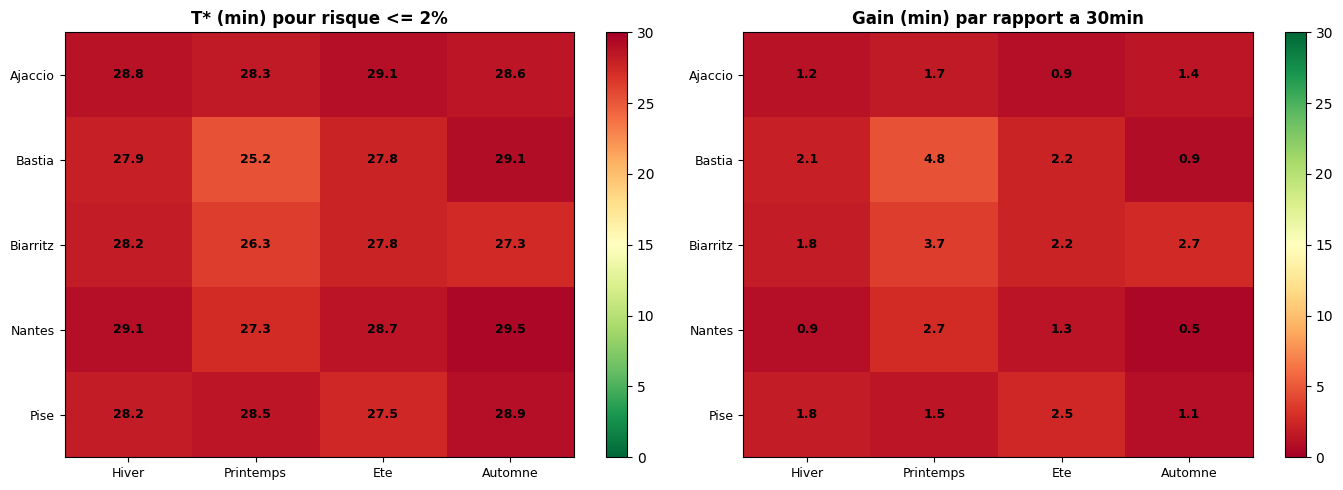


TABLEAU CROISE : T* a 2% de risque
Airport      Saison        N alertes    T* 2%    Gain 2%    T* 5%    Gain 5% Note
------------------------------------------------------------------------------------------
Ajaccio      Automne             214     28.6        1.4     26.2        3.8 
Ajaccio      Ete                 145     29.1        0.9     27.2        2.8 
Ajaccio      Hiver                92     28.8        1.2     25.1        4.9 
Ajaccio      Printemps            79     28.3        1.7     22.1        7.9 
Bastia       Automne             178     29.1        0.9     25.9        4.1 
Bastia       Ete                 177     27.8        2.2     26.4        3.6 
Bastia       Hiver                71     27.9        2.1     25.9        4.1 
Bastia       Printemps           106     25.2        4.8     23.6        6.4 
Biarritz     Automne             158     27.3        2.7     23.1        6.9 
Biarritz     Ete                 190     27.8        2.2     25.5        4.5 
Biarritz   

In [7]:
resultats_croise = []

for airport in airports:
    for sais_id, sais_label in saison_labels.items():
        sub = df_surv[
            (df_surv['airport'] == airport) &
            (df_surv['saison']  == sais_id)
        ].dropna(subset=['duree'])

        n_alertes = sub['airport_alert_id'].nunique()
        if len(sub) < 30 or n_alertes < 5:
            resultats_croise.append({
                'airport': airport, 'saison': sais_label,
                'n_alertes': n_alertes, 'n_eclairs': len(sub),
                'T* 2%': np.nan, 'Gain 2%': 0,
                'T* 5%': np.nan, 'Gain 5%': 0,
                'note': 'Donnees insuffisantes'
            })
            continue

        t, s = kaplan_meier_estimator(sub['event'].values, sub['duree'].values)
        t2, r2 = trouver_t_star(t, s, 0.02)
        t5, r5 = trouver_t_star(t, s, 0.05)
        resultats_croise.append({
            'airport': airport, 'saison': sais_label,
            'n_alertes': n_alertes, 'n_eclairs': len(sub),
            'T* 2%': t2,  'Gain 2%': 30 - t2 if not np.isnan(t2) else 0,
            'T* 5%': t5,  'Gain 5%': 30 - t5 if not np.isnan(t5) else 0,
            'note': ''
        })

df_croise = pd.DataFrame(resultats_croise)

# Heatmap du T* a 2%
pivot_t2   = df_croise.pivot(index='airport', columns='saison', values='T* 2%')
pivot_gain = df_croise.pivot(index='airport', columns='saison', values='Gain 2%')
ordre_sais = ['Hiver', 'Printemps', 'Ete', 'Automne']
pivot_t2   = pivot_t2.reindex(columns=[s for s in ordre_sais if s in pivot_t2.columns])
pivot_gain = pivot_gain.reindex(columns=[s for s in ordre_sais if s in pivot_gain.columns])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pivot, title, fmt in [
    (axes[0], pivot_t2,   'T* (min) pour risque <= 2%',   '{:.1f}'),
    (axes[1], pivot_gain, 'Gain (min) par rapport a 30min', '{:.1f}'),
]:
    vals = pivot.values.astype(float)
    im = ax.imshow(vals, cmap='RdYlGn_r' if 'T*' in title else 'RdYlGn',
                   aspect='auto', vmin=0, vmax=30)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            txt = fmt.format(v) if not np.isnan(v) else 'N/A'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black' if not np.isnan(v) else 'gray')

plt.tight_layout()
plt.savefig('km_croise_aeroport_saison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 90)
print('TABLEAU CROISE : T* a 2% de risque')
print('=' * 90)
print(f"{'Airport':<12} {'Saison':<12} {'N alertes':>10} {'T* 2%':>8} {'Gain 2%':>10} {'T* 5%':>8} {'Gain 5%':>10} Note")
print('-' * 90)
for _, row in df_croise.sort_values(['airport', 'saison']).iterrows():
    t2_str = f"{row['T* 2%']:.1f}" if not np.isnan(row['T* 2%']) else 'impossible'
    g2_str = f"{row['Gain 2%']:.1f}" if not np.isnan(row['T* 2%']) else '--'
    t5_str = f"{row['T* 5%']:.1f}" if not np.isnan(row['T* 5%']) else 'impossible'
    g5_str = f"{row['Gain 5%']:.1f}" if not np.isnan(row['T* 5%']) else '--'
    print(f"{row['airport']:<12} {row['saison']:<12} {int(row['n_alertes']):>10} {t2_str:>8} {g2_str:>10} {t5_str:>8} {g5_str:>10} {row['note']}")

## SECTION 7 : Synthese -- le KM permet-il de descendre sous 2% ?

In [8]:
print('=' * 70)
print('SYNTHESE : KM PEUT-IL ATTEINDRE 2% DE RISQUE ?')
print('=' * 70)

# KM global
t2_global, r2_global = trouver_t_star(t_km, s_km, 0.02)
t5_global, r5_global = trouver_t_star(t_km, s_km, 0.05)

if not np.isnan(t2_global):
    print(f'KM global :  T*={t2_global:.1f} min -> risque {r2_global*100:.2f}%  (gain {30-t2_global:.1f} min)')
else:
    print('KM global : impossible d\'atteindre 2% de risque')

print()
print('Par aeroport, peut-on atteindre 2% de risque ?')
print('-' * 60)
for _, row in df_res_ap.iterrows():
    if np.isnan(row['T* 2%']):
        print(f"  {row['airport']:<12} NON  (S(30) trop elevee : {row['S(30)']*100:.2f}%)")
    else:
        print(f"  {row['airport']:<12} OUI  T*={row['T* 2%']:.1f} min  gain={row['Gain 2%']:.1f} min")

print()
print('Par saison, peut-on atteindre 2% de risque ?')
print('-' * 60)
for _, row in df_res_sais.iterrows():
    if np.isnan(row['T* 2%']):
        print(f"  {row['saison']:<12} NON")
    else:
        print(f"  {row['saison']:<12} OUI  T*={row['T* 2%']:.1f} min  gain={row['Gain 2%']:.1f} min")

print()
print('Groupes aeroport x saison atteignant 2% avec gain > 2 min :')
print('-' * 60)
bons = df_croise[~df_croise['T* 2%'].isna() & (df_croise['Gain 2%'] > 2)].sort_values('Gain 2%', ascending=False)
if len(bons) == 0:
    print('  Aucun groupe ne permet de gagner plus de 2 min a 2% de risque')
else:
    for _, row in bons.iterrows():
        print(f"  {row['airport']:<12} {row['saison']:<12} T*={row['T* 2%']:.1f} min  gain={row['Gain 2%']:.1f} min  (n={int(row['n_alertes'])} alertes)")

print()
print('CONCLUSION')
print('-' * 60)
n_ok_ap   = df_res_ap['T* 2%'].notna().sum()
n_ok_sais = df_res_sais['T* 2%'].notna().sum()
print(f'{n_ok_ap}/{len(df_res_ap)} aeroports peuvent atteindre 2% avec le KM')
print(f'{n_ok_sais}/{len(df_res_sais)} saisons peuvent atteindre 2% avec le KM')
print()
print('Interpretation :')
print('  - Si 2% est possible avec KM : la regle fixe peut etre abaissee pour ce groupe')
print('  - Si 2% est impossible avec KM : seul un modele ML personnalise (RSF) peut y arriver')
print('  - car le KM dit ce qui est vrai EN MOYENNE pour ce groupe,')
print('    le RSF peut identifier QUELS orages specifiques permettent de lever plus tot')

SYNTHESE : KM PEUT-IL ATTEINDRE 2% DE RISQUE ?
KM global :  T*=28.5 min -> risque 1.98%  (gain 1.5 min)

Par aeroport, peut-on atteindre 2% de risque ?
------------------------------------------------------------
  Ajaccio      OUI  T*=28.6 min  gain=1.4 min
  Bastia       OUI  T*=28.4 min  gain=1.6 min
  Biarritz     OUI  T*=27.3 min  gain=2.7 min
  Nantes       OUI  T*=28.9 min  gain=1.1 min
  Pise         OUI  T*=28.3 min  gain=1.7 min

Par saison, peut-on atteindre 2% de risque ?
------------------------------------------------------------
  Hiver        OUI  T*=28.2 min  gain=1.8 min
  Printemps    OUI  T*=28.0 min  gain=2.0 min
  Ete          OUI  T*=28.6 min  gain=1.4 min
  Automne      OUI  T*=28.8 min  gain=1.2 min

Groupes aeroport x saison atteignant 2% avec gain > 2 min :
------------------------------------------------------------
  Bastia       Printemps    T*=25.2 min  gain=4.8 min  (n=106 alertes)
  Biarritz     Printemps    T*=26.3 min  gain=3.7 min  (n=142 alertes)
  